In [ ]:
# Install required packages (if needed)
!pip install tensorflow numpy pandas scikit-learn matplotlib seaborn

# Import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.layers import Bidirectional, GRU, Dense, Dropout, Concatenate, Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Load your dataset

df = pd.read_csv('final_dataset (1).csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nDataset Info:")
print(df.info())

print(f"\nClass Distribution:")
print(df['label'].value_counts())
print(f"\nClass Balance: {df['label'].value_counts(normalize=True)}")

# Check for missing values
print(f"\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (827993, 13)

First few rows:
                                        URL  LengthOfURL  \
0                  http://www.tkk.fbcode.co           24   
1  https://kinhh.formstack.com/forms/bigwig           40   
2      https://atrezorsigniin.gitbook.io/us           36   
3         https://bt-105613.weeblysite.com/           33   
4             https://www.phillipschevy.com           29   

                      Domain  DomainLengthOfURL  IsDomainIP  LetterCntInURL  \
0          www.tkk.fbcode.co                 17           0              11   
1        kinhh.formstack.com                 19           0              28   
2  atrezorsigniin.gitbook.io                 25           0              25   
3   bt-105613.weeblysite.com                 24           0              15   
4      www.phillipschevy.com                 21           0              16   

   URLLetterRatio  DigitCntInURL  ShannonEntropy  KolmogorovComplexity  \
0           0.458              0        3.558

In [ ]:
# Configuration parameters
MAX_URL_LENGTH = 200  # Maximum URL length to consider
VOCAB_SIZE = 100      # Character vocabulary size
EMBEDDING_DIM = 64    # Character embedding dimension

# Extract URLs and labels
urls = df['URL'].values
labels = df['label'].values

# Create character-level tokenizer
tokenizer = Tokenizer(char_level=True, lower=True, oov_token='<OOV>')
tokenizer.fit_on_texts(urls)

# Convert URLs to sequences
url_sequences = tokenizer.texts_to_sequences(urls)

# Pad sequences to uniform length
url_padded = pad_sequences(url_sequences, maxlen=MAX_URL_LENGTH, padding='post', truncating='post')

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"URL Sequences Shape: {url_padded.shape}")
print(f"\nExample URL: {urls[0]}")
print(f"Tokenized: {url_sequences[0][:20]}...")  # Show first 20 tokens
print(f"Padded Shape: {url_padded[0].shape}")


Vocabulary Size: 1189
URL Sequences Shape: (827993, 200)

Example URL: http://www.tkk.fbcode.co
Tokenized: [15, 2, 2, 10, 24, 3, 3, 14, 14, 14, 13, 2, 26, 26, 13, 22, 21, 11, 8, 16]...
Padded Shape: (200,)


In [ ]:
# Extract the 13 numerical features
feature_columns = ['LengthOfURL', 'Domain', 'DomainLengthOfURL', 'IsDomainIP',
                   'LetterCntInURL', 'URLLetterRatio', 'DigitCntInURL',
                   'ShannonEntropy', 'KolmogorovComplexity', 'HexPatternCnt',
                   'Base64PatternCnt']

# Note: 'Domain' column appears to be text, you may need to encode or remove it
# For now, we'll exclude 'Domain' and use only numerical features
numerical_features = ['LengthOfURL', 'DomainLengthOfURL', 'IsDomainIP',
                      'LetterCntInURL', 'URLLetterRatio', 'DigitCntInURL',
                      'ShannonEntropy', 'KolmogorovComplexity', 'HexPatternCnt',
                      'Base64PatternCnt']

features = df[numerical_features].values

# Normalize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(f"Feature Shape: {features_scaled.shape}")
print(f"\nFeature Statistics (after scaling):")
print(pd.DataFrame(features_scaled, columns=numerical_features).describe())


Feature Shape: (827993, 10)

Feature Statistics (after scaling):
        LengthOfURL  DomainLengthOfURL    IsDomainIP  LetterCntInURL  \
count  8.279930e+05       8.279930e+05  8.279930e+05    8.279930e+05   
mean  -4.094237e-17      -9.699141e-17  3.153704e-17    2.212312e-17   
std    1.000001e+00       1.000001e+00  1.000001e+00    1.000001e+00   
min   -3.455713e-01      -2.039468e+00 -2.414350e-01   -4.018080e-01   
25%   -2.375322e-01      -6.160821e-01 -2.414350e-01   -2.425984e-01   
50%   -1.294931e-01      -2.278859e-01 -2.414350e-01   -1.336656e-01   
75%   -2.388278e-03       2.897090e-01 -2.414350e-01    1.716454e-02   
max    7.816072e+01       1.348838e+01  4.141902e+00    6.085197e+01   

       URLLetterRatio  DigitCntInURL  ShannonEntropy  KolmogorovComplexity  \
count    8.279930e+05   8.279930e+05    8.279930e+05          8.279930e+05   
mean     2.564154e-16   5.063089e-19   -2.667604e-15          3.089171e-15   
std      1.000001e+00   1.000001e+00    1.000001e+00

In [ ]:
# Split data into train, validation, and test sets
# First split: 80% train+val, 20% test
X_url_temp, X_url_test, X_feat_temp, X_feat_test, y_temp, y_test = train_test_split(
    url_padded, features_scaled, labels, test_size=0.2, random_state=42, stratify=labels
)

# Second split: 87.5% train, 12.5% validation (of the 80%)
X_url_train, X_url_val, X_feat_train, X_feat_val, y_train, y_val = train_test_split(
    X_url_temp, X_feat_temp, y_temp, test_size=0.15625, random_state=42, stratify=y_temp
)

print(f"Training Set: {X_url_train.shape[0]} samples")
print(f"Validation Set: {X_url_val.shape[0]} samples")
print(f"Test Set: {X_url_test.shape[0]} samples")

print(f"\nTraining Label Distribution:")
print(pd.Series(y_train).value_counts(normalize=True))


Training Set: 558894 samples
Validation Set: 103500 samples
Test Set: 165599 samples

Training Label Distribution:
1    0.505536
0    0.494464
Name: proportion, dtype: float64


In [ ]:
def build_cnn_bigru_model(max_length, vocab_size, embedding_dim, num_features):
    """
    Build hybrid CNN+BiGRU model with feature integration
    """

    # URL Input Branch (Character-level CNN+BiGRU)
    url_input = Input(shape=(max_length,), name='url_input')

    # Character Embedding Layer
    embedding = Embedding(input_dim=vocab_size,
                         output_dim=embedding_dim,
                         input_length=max_length,
                         name='char_embedding')(url_input)

    # Parallel CNN layers with different kernel sizes
    conv1 = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding)
    conv1 = MaxPooling1D(pool_size=2)(conv1)

    conv2 = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(embedding)
    conv2 = MaxPooling1D(pool_size=2)(conv2)

    conv3 = Conv1D(filters=128, kernel_size=7, activation='relu', padding='same')(embedding)
    conv3 = MaxPooling1D(pool_size=2)(conv3)

    # Concatenate CNN outputs
    cnn_concat = Concatenate()([conv1, conv2, conv3])

    # BiGRU Layer
    bigru = Bidirectional(GRU(128, return_sequences=False, dropout=0.2))(cnn_concat)

    # Feature Input Branch
    feature_input = Input(shape=(num_features,), name='feature_input')
    feature_dense = Dense(64, activation='relu')(feature_input)
    feature_dense = Dropout(0.3)(feature_dense)

    # Merge URL and Feature branches
    merged = Concatenate()([bigru, feature_dense])

    # Final Dense Layers
    dense1 = Dense(256, activation='relu')(merged)
    dense1 = Dropout(0.3)(dense1)

    dense2 = Dense(128, activation='relu')(dense1)
    dense2 = Dropout(0.2)(dense2)

    # Output Layer
    output = Dense(1, activation='sigmoid', name='output')(dense2)

    # Create Model
    model = Model(inputs=[url_input, feature_input], outputs=output)

    return model

# Build the model
model = build_cnn_bigru_model(
    max_length=MAX_URL_LENGTH,
    vocab_size=len(tokenizer.word_index) + 1,
    embedding_dim=EMBEDDING_DIM,
    num_features=features_scaled.shape[1]
)

# Display model architecture
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ url_input           │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embedding      │ (None, 200, 64)   │     76,160 │ url_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 128)  │     24,704 │ char_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 200, 128)  │     41,088 │ char_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 200, 128)  │     57,472 │ char_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 100, 128)  │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 100, 128)  │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 100, 128)  │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100, 384)  │          0 │ max_pooling1d[0]… │
│ (Concatenate)       │                   │            │ max_pooling1d_1[… │
│                     │                   │            │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        704 │ feature_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256)       │    394,752 │ concatenate[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 320)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     82,176 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 710,081 (2.71 MB)

 Trainable params: 710,081 (2.71 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

print("Model compiled successfully!")


Model compiled successfully!


In [ ]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_phishing_model.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]

print("Callbacks configured!")


Callbacks configured!


In [ ]:
# Train the model
BATCH_SIZE = 128
EPOCHS = 15

history = model.fit(
    [X_url_train, X_feat_train],
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=([X_url_val, X_feat_val], y_val),
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")


Epoch 1/15
4367/4367 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9794 - auc: 0.9946 - loss: 0.0546 - precision: 0.9766 - recall: 0.9832
Epoch 1: val_auc improved from -inf to 0.99948, saving model to best_phishing_model.h5


4367/4367 ━━━━━━━━━━━━━━━━━━━━ 179s 38ms/step - accuracy: 0.9794 - auc: 0.9946 - loss: 0.0546 - precision: 0.9766 - recall: 0.9832 - val_accuracy: 0.9988 - val_auc: 0.9995 - val_loss: 0.0058 - val_precision: 0.9978 - val_recall: 0.9999 - learning_rate: 0.0010
Epoch 2/15
4367/4367 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9988 - auc: 0.9995 - loss: 0.0064 - precision: 0.9982 - recall: 0.9994
Epoch 2: val_auc improved from 0.99948 to 0.99961, saving model to best_phishing_model.h5


4367/4367 ━━━━━━━━━━━━━━━━━━━━ 166s 38ms/step - accuracy: 0.9988 - auc: 0.9995 - loss: 0.0064 - precision: 0.9982 - recall: 0.9994 - val_accuracy: 0.9991 - val_auc: 0.9996 - val_loss: 0.0051 - val_precision: 0.9984 - val_recall: 0.9999 - learning_rate: 0.0010
Epoch 3/15
4367/4367 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9991 - auc: 0.9996 - loss: 0.0049 - precision: 0.9986 - recall: 0.9996
Epoch 3: val_auc did not improve from 0.99961
4367/4367 ━━━━━━━━━━━━━━━━━━━━ 165s 38ms/step - accuracy: 0.9991 - auc: 0.9996 - loss: 0.0049 - precision: 0.9986 - recall: 0.9996 - val_accuracy: 0.9992 - val_auc: 0.9995 - val_loss: 0.0045 - val_precision: 0.9986 - val_recall: 0.9999 - learning_rate: 0.0010
Epoch 4/15
4367/4367 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9991 - auc: 0.9996 - loss: 0.0048 - precision: 0.9986 - recall: 0.9997
Epoch 4: val_auc did not improve from 0.99961
4367/4367 ━━━━━━━━━━━━━━━━━━━━ 166s 38ms/step - accuracy: 0.9991 - auc: 0.9996 - loss: 0.0048 - precision: 0

4367/4367 ━━━━━━━━━━━━━━━━━━━━ 166s 38ms/step - accuracy: 0.9993 - auc: 0.9997 - loss: 0.0039 - precision: 0.9989 - recall: 0.9998 - val_accuracy: 0.9993 - val_auc: 0.9997 - val_loss: 0.0045 - val_precision: 0.9986 - val_recall: 0.9999 - learning_rate: 0.0010
Epoch 7/15
4366/4367 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9993 - auc: 0.9997 - loss: 0.0036 - precision: 0.9989 - recall: 0.9998
Epoch 7: val_auc did not improve from 0.99972
4367/4367 ━━━━━━━━━━━━━━━━━━━━ 166s 38ms/step - accuracy: 0.9993 - auc: 0.9997 - loss: 0.0036 - precision: 0.9989 - recall: 0.9998 - val_accuracy: 0.9993 - val_auc: 0.9995 - val_loss: 0.0041 - val_precision: 0.9987 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 8/15
4367/4367 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9994 - auc: 0.9998 - loss: 0.0033 - precision: 0.9991 - recall: 0.9998
Epoch 8: val_auc did not improve from 0.99972
4367/4367 ━━━━━━━━━━━━━━━━━━━━ 165s 38ms/step - accuracy: 0.9994 - auc: 0.9998 - loss: 0.0033 - precision: 0

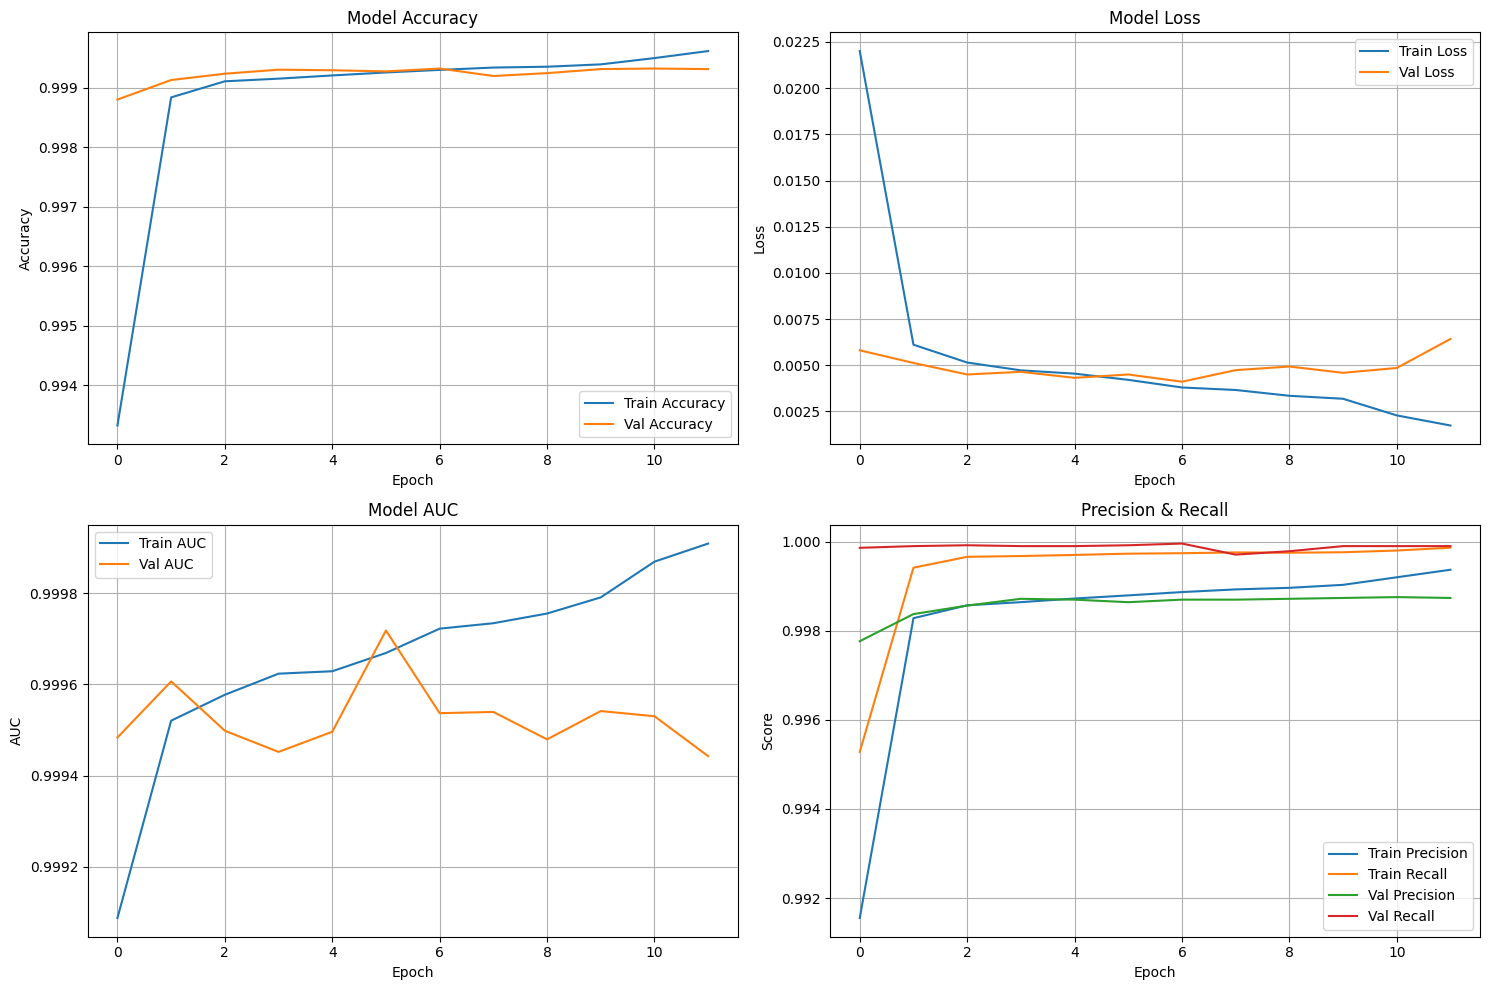

In [ ]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train Loss')
axes[0, 1].plot(history.history['val_loss'], label='Val Loss')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# AUC
axes[1, 0].plot(history.history['auc'], label='Train AUC')
axes[1, 0].plot(history.history['val_auc'], label='Val AUC')
axes[1, 0].set_title('Model AUC')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Precision and Recall
axes[1, 1].plot(history.history['precision'], label='Train Precision')
axes[1, 1].plot(history.history['recall'], label='Train Recall')
axes[1, 1].plot(history.history['val_precision'], label='Val Precision')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Precision & Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Load best model
model = keras.models.load_model('best_phishing_model.h5')

# Evaluate on test set
test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(
    [X_url_test, X_feat_test],
    y_test,
    verbose=1
)

print("\n" + "="*50)
print("TEST SET PERFORMANCE")
print("="*50)
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test F1-Score:  {2 * (test_precision * test_recall) / (test_precision + test_recall):.4f}")


5175/5175 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - accuracy: 0.9993 - auc: 0.9998 - loss: 0.0040 - precision: 0.9986 - recall: 0.9999

TEST SET PERFORMANCE
Test Accuracy:  0.9992
Test Precision: 0.9986
Test Recall:    0.9999
Test AUC:       0.9998
Test F1-Score:  0.9992


5175/5175 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step


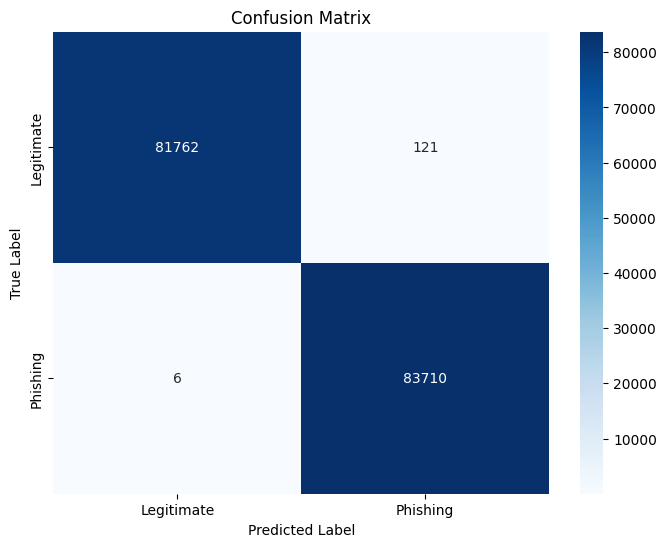


Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     81883
    Phishing       1.00      1.00      1.00     83716

    accuracy                           1.00    165599
   macro avg       1.00      1.00      1.00    165599
weighted avg       1.00      1.00      1.00    165599



In [ ]:
# Generate predictions
y_pred_proba = model.predict([X_url_test, X_feat_test])
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))


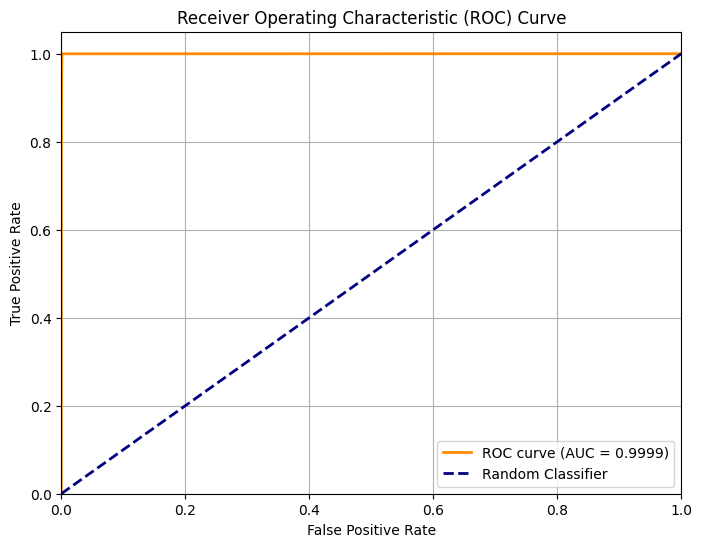

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
# SIMPLIFIED MODEL SAVING CODE 

import pickle
import json
from datetime import datetime

print("="*80)
print("SAVING PHISHING DETECTION MODEL")
print("="*80)

# 1. Save the trained model
print("\n1. Saving trained model...")
model.save('phishing_cnn_bigru_model.h5')
print("   ✓ Model saved as: phishing_cnn_bigru_model.h5")

# 2. Save the tokenizer
print("\n2. Saving tokenizer...")
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("   ✓ Tokenizer saved as: tokenizer.pkl")

# 3. Save the scaler
print("\n3. Saving feature scaler...")
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("   ✓ Scaler saved as: scaler.pkl")

